In [3]:
import pandas as pd
df_loan = pd.read_csv("C:/Users/admin/Downloads/datasets/loan_portfolio_dataset.csv")

In [4]:
df_loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   loan_id                800000 non-null  int64  
 1   customer_segment       800000 non-null  str    
 2   sanction_amount        800000 non-null  int64  
 3   outstanding_principal  800000 non-null  int64  
 4   interest_rate          800000 non-null  float64
 5   repricing_frequency    800000 non-null  str    
 6   prepayment_option      800000 non-null  str    
 7   collateral_type        800000 non-null  str    
 8   region                 800000 non-null  str    
 9   tenure_months          800000 non-null  int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 84.3 MB


In [1]:
import pandas as pd
df_borr = pd.read_csv("C:/Users/admin/Downloads/datasets/borrowing_funding_dataset.csv")

In [2]:
df_borr.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   borrowing_id         200000 non-null  int64  
 1   funding_source       200000 non-null  str    
 2   cost_of_funds        200000 non-null  float64
 3   maturity_bucket      200000 non-null  str    
 4   interest_reset_type  200000 non-null  str    
 5   borrowing_amount     200000 non-null  int64  
 6   rollover_risk_score  200000 non-null  float64
dtypes: float64(2), int64(2), str(3)
memory usage: 14.1 MB


In [5]:
import pandas as pd
df_cash = pd.read_csv("C:/Users/admin/Downloads/datasets/daily_cashflow_dataset.csv")

In [6]:
df_cash.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   date             300000 non-null  str  
 1   inflow_type      300000 non-null  str  
 2   outflow_type     300000 non-null  str  
 3   expected_amount  300000 non-null  int64
 4   actual_amount    300000 non-null  int64
 5   variance         300000 non-null  int64
dtypes: int64(3), str(3)
memory usage: 23.4 MB


In [7]:
import pandas as pd
df_macro = pd.read_csv("C:/Users/admin/Downloads/datasets/market_macro_dataset.csv")

In [8]:
df_macro.info()

<class 'pandas.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   date             600000 non-null  str    
 1   repo_rate        600000 non-null  float64
 2   gsec_10y         600000 non-null  float64
 3   cp_rate          600000 non-null  float64
 4   inflation_cpi    600000 non-null  float64
 5   liquidity_index  600000 non-null  float64
 6   usd_inr          600000 non-null  float64
dtypes: float64(6), str(1)
memory usage: 37.8 MB


In [9]:
total_asset_exposure = df_loan['outstanding_principal'].sum()


In [10]:
total_asset_exposure 

np.int64(1603450456828)

In [11]:
total_liability_exposure = df_borr['borrowing_amount'].sum()


In [12]:
total_liability_exposure

np.int64(5093760528694)

In [13]:
net_alm_gap = total_asset_exposure - total_liability_exposure


In [14]:
net_alm_gap

np.int64(-3490310071866)

In [16]:
df_loan.tenure_months

0         144
1          18
2          51
3          21
4          91
         ... 
799995    135
799996    139
799997     15
799998    109
799999    173
Name: tenure_months, Length: 800000, dtype: int64

In [17]:
df_borr.maturity_bucket

0         6M
1         6M
2         6M
3         3Y
4         3Y
          ..
199995    3Y
199996    3M
199997    3M
199998    3M
199999    3M
Name: maturity_bucket, Length: 200000, dtype: str

In [20]:

df_borr[['value', 'unit']] = df_borr['maturity_bucket'].str.extract(r'(\d+)([MY])')


df_borr['value'] = df_borr['value'].astype(int)

In [21]:
df_borr['maturity_days'] = df_borr.apply(
    lambda x: x['value'] * 30 if x['unit'] == 'M' else x['value'] * 365,
    axis=1
)

In [22]:
df_borr['maturity_days'] 

0          180
1          180
2          180
3         1095
4         1095
          ... 
199995    1095
199996      90
199997      90
199998      90
199999      90
Name: maturity_days, Length: 200000, dtype: int64

In [24]:
short_term_assets = df_loan[df_loan['tenure_months'] <= 90]['outstanding_principal'].sum()
short_term_liabilities = df_borr[df_borr['maturity_days'] <= 90]['borrowing_amount'].sum()

In [25]:
short_term_gap = short_term_assets - short_term_liabilities

In [26]:
short_term_gap

np.int64(-1481556696747)

In [28]:
cumulative_gap = net_alm_gap.sum()

In [29]:
cumulative_gap

np.int64(-3490310071866)

In [30]:
df_borr['funding_risk_exposure'] = df_borr['borrowing_amount'] * df_borr['rollover_risk_score'].sum()




In [31]:
df_borr['funding_risk_exposure'] 

0         8.945531e+11
1         3.140318e+12
2         2.196711e+12
3         1.175933e+12
4         4.352802e+12
              ...     
199995    1.898531e+12
199996    1.062690e+12
199997    3.361149e+12
199998    4.469188e+12
199999    1.403426e+12
Name: funding_risk_exposure, Length: 200000, dtype: float64

In [32]:
short_term_borrowing = df_borr[df_borr['maturity_days'] <= 90]['borrowing_amount'].sum()
total_borrowing = df_borr['borrowing_amount'].sum()

short_term_ratio = short_term_borrowing / total_borrowing


In [33]:
short_term_ratio 

np.float64(0.39991112269981094)

In [5]:
assets = df_loan['outstanding_principal'].sum()

In [7]:
assets

np.int64(1603450456828)

In [6]:
liabilities = df_borr['borrowing_amount'].sum()

In [8]:
liabilities

np.int64(5093760528694)

In [9]:
df_borr['alm_gap'] = assets-liabilities

In [10]:
df_borr['alm_gap']

0        -3490310071866
1        -3490310071866
2        -3490310071866
3        -3490310071866
4        -3490310071866
              ...      
199995   -3490310071866
199996   -3490310071866
199997   -3490310071866
199998   -3490310071866
199999   -3490310071866
Name: alm_gap, Length: 200000, dtype: int64

In [11]:
df_borr.maturity_bucket

0         6M
1         6M
2         6M
3         3Y
4         3Y
          ..
199995    3Y
199996    3M
199997    3M
199998    3M
199999    3M
Name: maturity_bucket, Length: 200000, dtype: str

In [12]:
def convert_to_days(x):
    if "M" in x:
        return int(x.replace("M", "")) * 30
    elif "Y" in x:
        return int(x.replace("Y", "")) * 365

# Apply conversion
df_borr["Days"] = df_borr["maturity_bucket"].apply(convert_to_days)

In [14]:
df_borr['Days']

0          180
1          180
2          180
3         1095
4         1095
          ... 
199995    1095
199996      90
199997      90
199998      90
199999      90
Name: Days, Length: 200000, dtype: int64

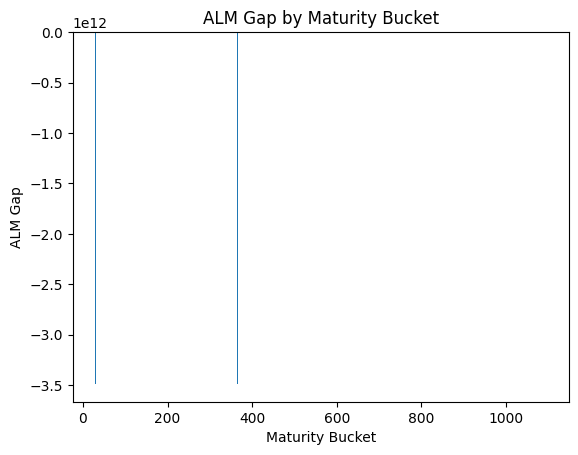

In [16]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(df_borr["Days"], df_borr["alm_gap"])

plt.xlabel("Maturity Bucket")
plt.ylabel("ALM Gap")
plt.title("ALM Gap by Maturity Bucket")

plt.show()

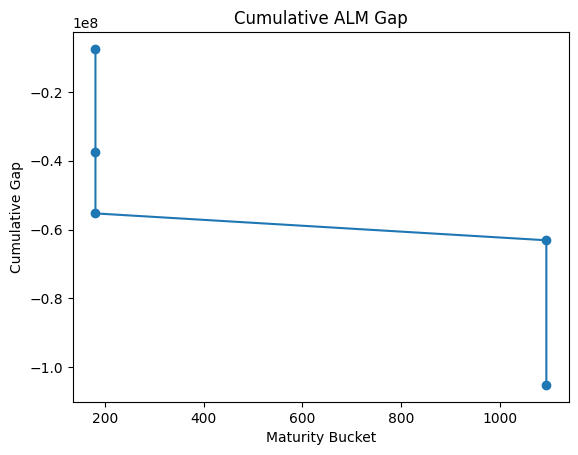

In [46]:
alm['cumulative_gap'] = alm['gap'].cumsum()

plt.figure()
plt.plot(alm['bucket'], alm['cumulative_gap'], marker='o')

plt.title("Cumulative ALM Gap")
plt.xlabel("Maturity Bucket")
plt.ylabel("Cumulative Gap")

plt.show()

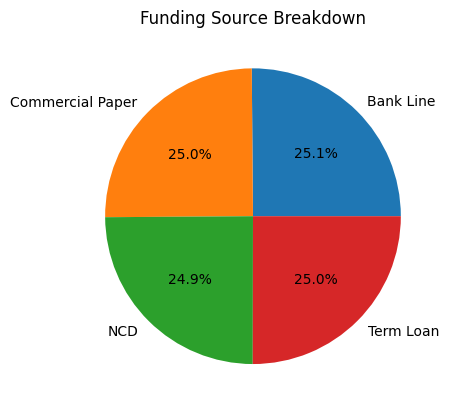

In [47]:
funding = df_borr.groupby('funding_source')['borrowing_amount'].sum()

plt.figure()
plt.pie(funding, labels=funding.index, autopct='%1.1f%%')

plt.title("Funding Source Breakdown")
plt.show()

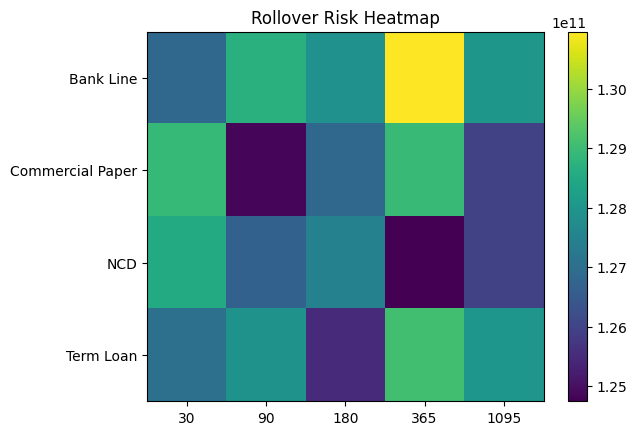

In [50]:
df_borr['risk_exposure'] = df_borr['borrowing_amount'] * df_borr['rollover_risk_score']

heatmap = pd.pivot_table(
    df_borr,
    values='risk_exposure',
    index='funding_source',
    columns='maturity_days',
    aggfunc='sum'
)

plt.figure()
plt.imshow(heatmap, aspect='auto')

plt.xticks(range(len(heatmap.columns)), heatmap.columns)
plt.yticks(range(len(heatmap.index)), heatmap.index)

plt.title("Rollover Risk Heatmap")

plt.colorbar()
plt.show()

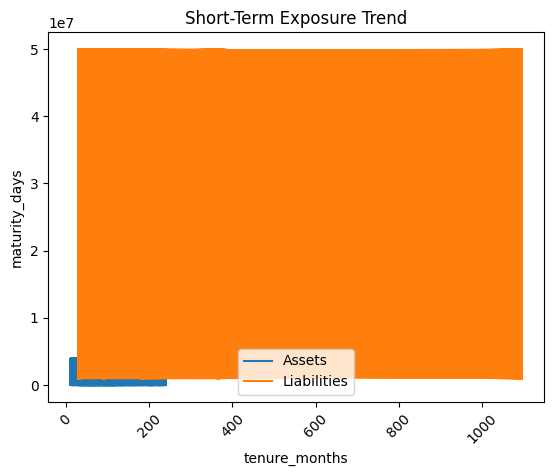

In [54]:
plt.figure()
plt.plot(df_loan['tenure_months'], df_loan['outstanding_principal'], label='Assets')
plt.plot(df_borr['maturity_days'], df_borr['borrowing_amount'], label='Liabilities')

plt.title("Short-Term Exposure Trend")
plt.xlabel("tenure_months")
plt.ylabel("maturity_days")

plt.legend()
plt.xticks(rotation=45)

plt.show()